#### 순서 1번 : 트랜스포머 ASR 코드 + 커스텀 코드 실행(음성파일 필요)

In [1]:
# 오디오 다운로드
!curl -o test.wav "https://developark.duckdns.org/api/public/dl/98dWiS5z/uploads/test.wav"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:--  0:00:01 --:--:--     0
100 31952  100 31952    0     0  16647      0  0:00:01  0:00:01 --:--:-- 16693


In [1]:
!pip install transformers torch librosa
# transformer ASR
from transformers import Wav2Vec2ForCTC, Wav2Vec2Processor
import torch
import librosa
import numpy as np

# 모델 및 프로세서 로드
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-large-960h")
model = Wav2Vec2ForCTC.from_pretrained("facebook/wav2vec2-large-960h")

# 오디오 파일 로드
audio, rate = librosa.load("test.wav", sr=16000)

# 전처리 및 예측
input_values = processor(audio, return_tensors="pt", sampling_rate=rate).input_values
with torch.no_grad():
    logits = model(input_values).logits

# 디코딩
predicted_ids = torch.argmax(logits, dim=-1)
transcription = processor.batch_decode(predicted_ids)[0]
print(f"인식결과 : {transcription}")

# 커스텀 코드 : logit과 mel_db. token, attn 정의
with torch.no_grad():
    logits = model(input_values).logits  # [1, T_in, Vocab]

# 2. 시각화 함수에 넣기 위한 데이터 가공
# (A) 멜 스펙트로그램 생성
S = librosa.feature.melspectrogram(y=audio, sr=rate, n_mels=350, hop_length=320) # Wav2Vec2는 보통 hop_length가 320 (20ms)
mel_db = librosa.power_to_db(S, ref=np.max)

# (B) 시간축 계산
T_in = logits.shape[1]
# Wav2Vec2의 다운샘플링 비율을 고려한 시간축 (보통 오디오 1초당 50프레임)
frame_times = np.arange(T_in) * (len(audio) / rate / T_in)

# (C) 가공된 토큰 리스트 (공백 ' '은 시각화 편의를 위해 '|' 등으로 표시 가능)
predicted_ids = torch.argmax(logits, dim=-1)[0]
predicted_tokens = [processor.tokenizer.decode([i]) if i != processor.tokenizer.pad_token_id else "-" for i in predicted_ids]

# (D) CTC Logits를 Attention Map처럼 변환 [1, 1, T_out, T_in]
# CTC는 T_out과 T_in이 같으므로, 대각선 방향의 확률 분포를 시각화합니다.
probs = torch.nn.functional.softmax(logits, dim=-1)
# 시각화를 위해 [Layers=1, Heads=1, T_out, T_in] 형태로 더미 차원 추가
# 여기서는 단순히 자기 자신의 확률값을 어텐션처럼 시각화합니다.
pseudo_attn = torch.zeros(1, 1, T_in, T_in)
for i in range(T_in):
    pseudo_attn[0, 0, i, i] = probs[0, i, predicted_ids[i]]

c:\Users\kj\anaconda3\envs\test1\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 404/404 [00:00<00:00, 6533.84it/s]
[transformers] Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-large-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


인식결과 : TESTIATESTIATESTA


#### 순서 2번 : 시각화를 위한 어텐션 히트맵 : 크로스어텐션 함수 정의

In [2]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
# -------------------------------------------
# (A) 어텐션 히트맵: 크로스 어텐션 [Layers, Heads, T_out, T_in]
# -------------------------------------------
def plot_cross_attention_heatmap(attn, out_tokens=None, frame_times=None, layer=0, head=0, title="Cross-Attention Weights"):
    """
    attn: np.ndarray [L, H, T_out, T_in] 또는 torch.Tensor
    out_tokens: 출력토큰(문자/음소) 리스트 길이 = T_out (y축 라벨용)
    frame_times: 각 입력 프레임의 초 단위 시간축(길이 T_in)
    """

    if isinstance(attn, torch.Tensor):
        attn = attn.detach().cpu().numpy()
        A = attn[layer, head]  # [T_out, T_in]

    plt.figure(figsize=(10, 6))
    plt.imshow(A, aspect="auto", origin="lower")  # y=0이 아래쪽으로 가도록
    plt.colorbar()
    
    plt.title(f"{title} (Layer {layer}, Head {head})")
    plt.ylabel("Output tokens (t)")
    plt.xlabel("Input frames (time)")

    if out_tokens is not None:
        yticks = np.arange(len(out_tokens))
        plt.yticks(yticks, out_tokens, fontsize=9)

    if frame_times is not None:
        xtick = np.linspace(0, len(frame_times)-1, num=10, dtype=int)
        xticklabs = [f"{frame_times[i]:.2f}s" for i in xtick]

    plt.xticks(xtick, xticklabs, rotation=45)
    plt.tight_layout()
    plt.show()

# -------------------------------------------
# (B) 멜 스펙토그램 위 정렬경로 오버레이
# - 각 출력 스템에서 Argmax 프레임을 꿰어 대략적 정렬선 시각화
# -------------------------------------------
def plot_alignment_on_mel(mel_db, attn_one_layer_head, frame_times=None, out_tokens=None, title="Alignment on Mel"):
    """
    mel_db: [F, T_in] (로그멜 dB 등) 2D
    attn_one_layer_head: [T_out, T_in] (단일 layer/head의 크로스 어텐션)
    frame_times: 길이 T_in, 초 단위
    """
 
    if isinstance(attn_one_layer_head, torch.Tensor):
        attn_one_layer_head = attn_one_layer_head.detach().cpu().numpy()

    # 멜디비 대입시
    if isinstance(mel_db, torch.Tensor):
        mel_db = mel_db.detach().cpu().numpy()

    # out_tokens 인수 부족을 보충(out_token의 인수부족이 의미가 없어서 주석처리)
    # if out_tokens is not None:
    #     yticks = np.arange(len(out_tokens))
    #     plt.yticks(yticks, out_tokens, fontsize=9)

    # 정렬경로 (각 출력 스템의 argmax 프레임)
    path = attn_one_layer_head.argmax(axis=1)  # [T_out]

    plt.figure(figsize=(10, 6))
    plt.imshow(mel_db, aspect="auto", origin="lower")
    plt.colorbar(label="dB")
    plt.title(title)
    plt.ylabel("Mel bins")
    plt.xlabel("Time (frames)")


    # 시간축 라벨 (선택)
    if frame_times is not None:
        xticks = np.linspace(0, len(frame_times)-1, num=10, dtype=int)
        xticklabs = [f"{frame_times[i]:.2f}s" for i in xticks]

    plt.xticks(xticks, xticklabs, rotation=45)

    # 정렬경로 오버레이 (빨간 점/선)
    t_out = np.arange(len(path))
    plt.plot(path, np.full_like(path, -5), alpha=0)  # 축 범위 보호용 더미
    plt.plot(path, np.linspace(2, 2, len(path)), alpha=0)  # 더미
    # 직선으로 되어 있는 빨간색을 제거하기 위해 주석처리
    # plt.scatter(path, np.linspace(mel_db.shape[0]*0.9, mel_db.shape[0]*0.9, len(path)), s=50, color="red")  # 위쪽 가장자리에 점 찍고

    # 실제 라인은 멜 축이 아니라 프레임 인덱스 변화를 보여주기 위해 보조축 사용
    ax = plt.gca().twiny()
    ax.plot(path, t_out, linewidth=1, color="red")
    ax.set_xlabel("Argmax frame per output step")
    plt.tight_layout()
    plt.show()

# -------------------------------------------
# (C) 토큰 신뢰도 : max prob & entropy 곡선
#  - logits: [T_out, V] 또는 [B, T_out, V]
# -------------------------------------------
def plot_token_confidence(logits, out_tokens=None, title="Token Confidence / Entropy"):
    if isinstance(logits, torch.Tensor):
        logits = logits.detach().cpu()
    
    if logits.ndim == 3:
        logits = logits[0]  # B=1 가정하면
    
    probs = F.softmax(torch.as_tensor(logits), dim=-1).numpy()  # [T_out, V]
    max_p = probs.max(axis=1)  # [T_out]
    
    # 엔트로피 H = -sum p log p
    eps = 1e-12
    entropy = -(probs * np.log(probs + eps)).sum(axis=1)
    t = np.arange(len(max_p))
    fig = plt.figure(figsize=(10, 5))
    ax1 = plt.gca()
    ax1.plot(t, max_p, label="Max Prob")
    ax1.set_xlabel("Output step")
    ax1.set_ylabel("Max Probability")
    ax1.set_title(title)
    ax2 = ax1.twinx()
    ax2.plot(t, entropy, label="Entropy", linestyle="--")
    ax2.set_ylabel("Entropy")
    
    # 토큰 라벨 (선택)
    if out_tokens is not None:
        xticks = np.arange(len(out_tokens))
    ax1.set_xticks(xticks)
    ax1.set_xticklabels(out_tokens, rotation=45, fontsize=9)
    fig.tight_layout()
    plt.show()

# --- (문제해결을 위한 추가) CTC 전용 확률 분포 히트맵 시각화 ---
def plot_ctc_prob_map(logits, processor, frame_times=None, title="Wav2Vec2 CTC Probabilities"):
    """
    logits: [1, T_in, Vocab] 형태의 모델 출력
    """
    # 1. 확률값 변환 (Softmax)
    probs = torch.nn.functional.softmax(logits, dim=-1)[0].detach().cpu().numpy() # [T_in, Vocab]
    
    # 2. 가시성을 위해 빈 사전(Blank/Pad) 및 자주 안 나오는 토큰 필터링
    # 전체 단어사전(Vocab)을 다 그리면 너무 큽니다.
    # 알파벳 A-Z와 스페이스(Wav2Vec2에서는 보통 |)만 선택
    vocab = processor.tokenizer.get_vocab()
    target_tokens = ['|'] + [chr(i) for i in range(ord('A'), ord('Z')+1)]
    target_indices = [vocab[t] for t in target_tokens if t in vocab]
    
    filtered_probs = probs[:, target_indices] # [T_in, filtered_Vocab]

    # 3. 시각화 (시간-토큰 확률 지도)
    plt.figure(figsize=(12, 6))
    # origin='lower'를 써서 A가 아래, Z가 위에 오도록 설정
    # 필터링된 확률지도를 전치(Transpose)해서 넣어줍니다. [filtered_Vocab, T_in]
    img = plt.imshow(filtered_probs.T, aspect="auto", origin="lower", cmap='viridis', vmax=0.8)
    plt.colorbar(img, label="Probability")
    
    plt.title(title)
    plt.ylabel("Characters")
    plt.xlabel("Time (seconds)")

    # y축 라벨 설정 (알파벳)
    plt.yticks(np.arange(len(target_tokens)), target_tokens)

    # x축 라벨 설정 (초 단위 시간)
    if frame_times is not None:
        num_ticks = 10
        indices = np.linspace(0, len(frame_times) - 1, num_ticks, dtype=int)
        plt.xticks(indices, [f"{frame_times[i]:.2f}s" for i in indices], rotation=90, fontsize=7)

    plt.tight_layout()
    plt.show()

#### 순서 3번 함수 실행 및 시각화

--- [1] CTC Probabilities Heatmap ---


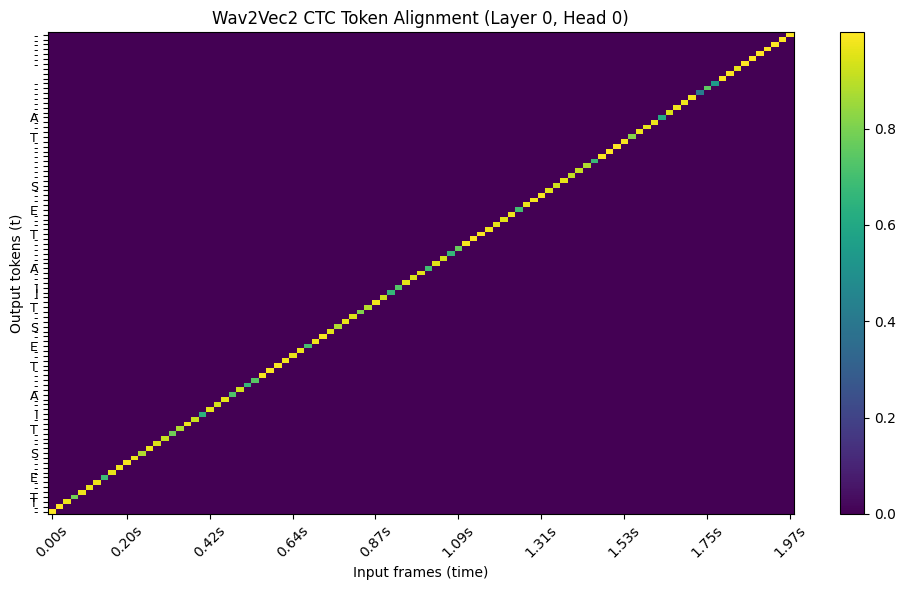

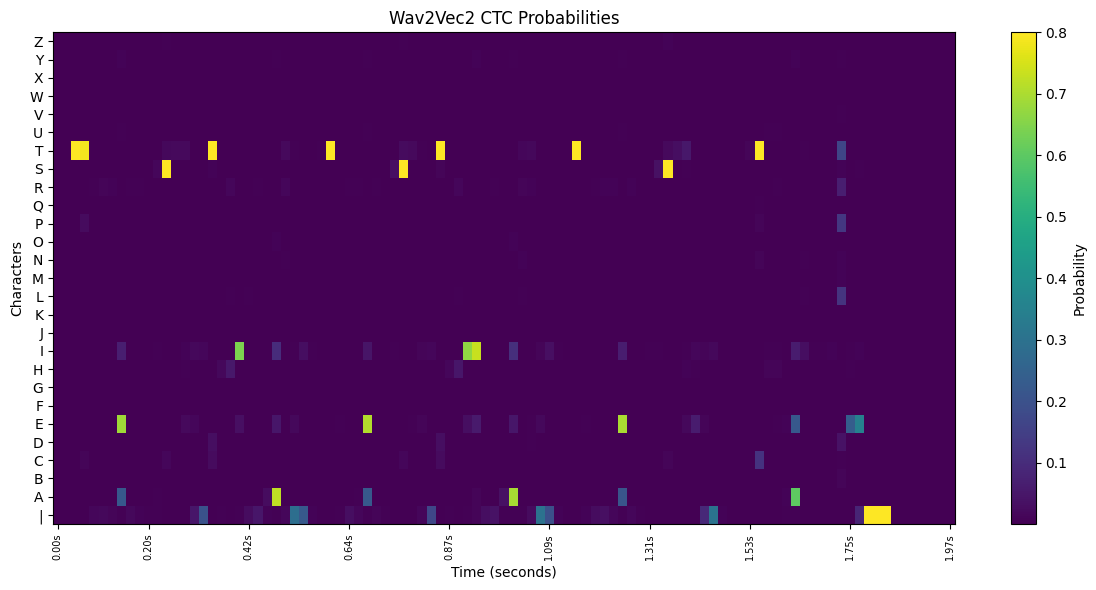

--- [2] Alignment on Mel ---


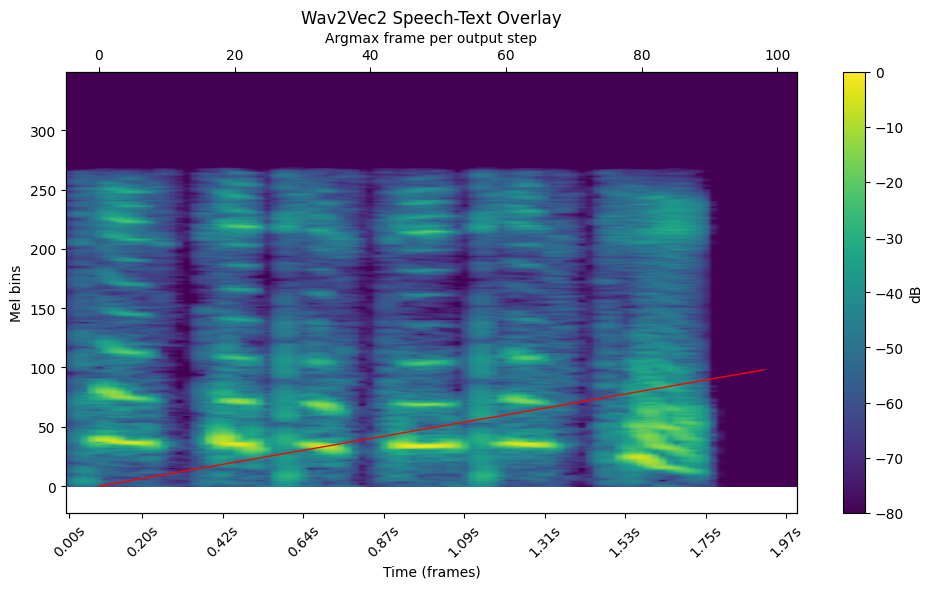

--- [3] Token Confidence ---


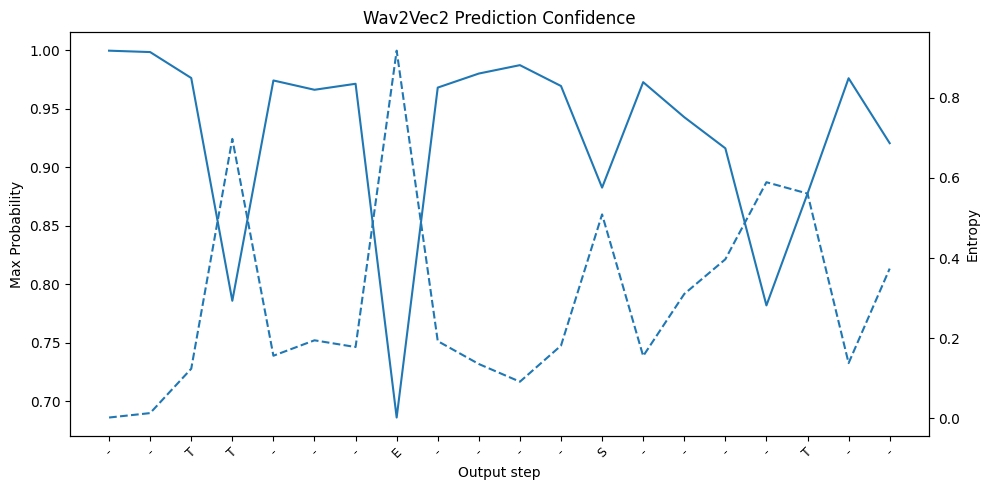

In [3]:
print("--- [1] CTC Probabilities Heatmap ---")
# Wav2Vec2는 토큰이 너무 많으므로 50개 프레임 단위로 잘라서 보거나, 일부 구간만 슬라이싱하는 것이 좋습니다.
plot_cross_attention_heatmap(
    attn=pseudo_attn, 
    out_tokens=predicted_tokens, 
    frame_times=frame_times,
    title="Wav2Vec2 CTC Token Alignment"
)

audio_duration = len(audio) / rate
T_in = logits.shape[1]
frame_times = np.arange(T_in) * (audio_duration / T_in)

# CTC 전용 함수 호출
plot_ctc_prob_map(logits, processor, frame_times=frame_times)

print("--- [2] Alignment on Mel ---")
plot_alignment_on_mel(
    mel_db=mel_db, 
    attn_one_layer_head=pseudo_attn[0, 0], 
    frame_times=frame_times,
    out_tokens=predicted_tokens,
    title="Wav2Vec2 Speech-Text Overlay"
)

print("--- [3] Token Confidence ---")
# 전체 문장을 한꺼번에 그리면 가독성이 떨어지므로 상위 20개 토큰만 예시로 시각화
plot_token_confidence(
    logits=logits[:, :20, :], 
    out_tokens=predicted_tokens[:20],
    title="Wav2Vec2 Prediction Confidence"
)